In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
#%matplotlib qt
cwd = '/home/lurishi/Escritorio/HeavenlyMCP/'
path = cwd + '/Data/MCP_flux/MCP_flux'

plt.rcParams.update({'font.family': 'serif'})

In [17]:
df_pi0_ = pd.read_csv(path + '/MCP_FROM_PI0_SURFACE.csv')
df_eta_ = pd.read_csv(path + '/MCP_FROM_ETA_SURFACE.csv')
df_omega_ = pd.read_csv(path + '/MCP_FROM_OMEGA_SURFACE.csv')
df_rho_ = pd.read_csv(path + '/MCP_FROM_RHO_SURFACE.csv')
df_phi_ = pd.read_csv(path + '/MCP_FROM_PHI_SURFACE.csv')
df_jpsi_ = pd.read_csv(path + '/MCP_FROM_JPSI_SURFACE.csv')
df_total_ = pd.read_csv(path + '/MCP_AllMesons_SURFACE_sum.csv')
eps2 = 1e-4
cos_theta = [0,1]
m_mcp = 0.1


In [18]:
E_chi_0 = []
E_chi_1 = []
f_diff_0 = []
f_diff_1 = []

for ct in cos_theta:
    df_eta = df_eta_[(df_eta_['eps2'] == eps2) & (df_eta_['cosTh'] == ct) & (df_eta_['m(GeV)'] == m_mcp)]
    df_omega = df_omega_[(df_omega_['eps2'] == eps2) & (df_omega_['cosTh'] == ct) & (df_omega_['m(GeV)'] == m_mcp)]
    df_rho = df_rho_[(df_rho_['eps2'] == eps2) & (df_rho_['cosTh'] == ct) & (df_rho_['m(GeV)'] == m_mcp)]
    df_phi = df_phi_[(df_phi_['eps2'] == eps2) & (df_phi_['cosTh'] == ct) & (df_phi_['m(GeV)'] == m_mcp)]
    df_jpsi = df_jpsi_[(df_jpsi_['eps2'] == eps2) & (df_jpsi_['cosTh'] == ct) & (df_jpsi_['m(GeV)'] == m_mcp)]
    #df_total = df_total_[(df_total_['eps2'] == eps2) & (df_total_['cos'] == ct) & (df_total_['m(GeV)'] == m_mcp)]
    E = [
        df_eta['Energy (GeV)'].values,
        df_omega['Energy (GeV)'].values,
        df_rho['Energy (GeV)'].values,
        df_phi['Energy (GeV)'].values,
        df_jpsi['Energy (GeV)'].values,
        #df_total['Energy (GeV)'].values,
    ]
    F = [
        df_eta['dphi_dEdCth(1/GeV/s/cm2)'].values,
        df_omega['dphi_dEdCth(1/GeV/s/cm2)'].values,
        df_rho['dphi_dEdCth(1/GeV/s/cm2)'].values,
        df_phi['dphi_dEdCth(1/GeV/s/cm2)'].values,
        df_jpsi['dphi_dEdCth(1/GeV/s/cm2)'].values,
        #df_total['flux_total'].values,
    ]

    if ct == 0:
        E_chi_0 = E
        f_diff_0 = F
    elif ct == 1:
        E_chi_1 = E
        f_diff_1 = F

E_chi = [E_chi_0, E_chi_1]
f_diff = [f_diff_0, f_diff_1]


In [19]:
def interpolate_total_flux(E_list, F_list, n_points=100):
    common_mass_ = np.unique(np.concatenate([np.asarray(m) for m in E_list]))
    print(len(common_mass_))

    common_mass = np.logspace(
        np.log10(common_mass_[0]),
        np.log10(common_mass_[-1]),
        n_points
    )

    flujo_md_interp = []
    for j in range(len(E_list)):
        mass_sorted_idx = np.argsort(E_list[j])
        mass_sorted = np.asarray(E_list[j])[mass_sorted_idx]
        flux_sorted = np.asarray(F_list[j])[mass_sorted_idx]

        unique_mask = np.concatenate(([True], np.diff(mass_sorted) != 0))
        mass_unique = mass_sorted[unique_mask]
        flux_unique = flux_sorted[unique_mask]

        flujo_md_interp.append(
            np.interp(common_mass, mass_unique, flux_unique, left=0.0, right=0.0)
        )

    flujo_total = np.sum(flujo_md_interp, axis=0)
    return common_mass, flujo_total

common_mass_0, flujo_total_0 = interpolate_total_flux(E_chi_0, f_diff_0)
common_mass_1, flujo_total_1 = interpolate_total_flux(E_chi_1, f_diff_1)

247
247


In [20]:
df = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/MD_cos_1.csv',sep=';')
df_0 = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/MD_cos_0.csv',sep=';')
df_0.head()

,Ex,flujo_total
0,0.718504,1.029570e-15
1,0.769941,2.072570e-15
2,0.835500,3.890900e-15
3,0.921000,8.019150e-15
4,1.005720,1.453820e-14


In [21]:
help(plt.subplots)

Help on function subplots in module matplotlib.pyplot:

subplots(
    nrows: int = 1,
    ncols: int = 1,
    *,
    sharex: bool | Literal['none', 'all', 'row', 'col'] = False,
    sharey: bool | Literal['none', 'all', 'row', 'col'] = False,
    squeeze: bool = True,
    width_ratios: Sequence[float] | None = None,
    height_ratios: Sequence[float] | None = None,
    subplot_kw: dict[str, Any] | None = None,
    gridspec_kw: dict[str, Any] | None = None,
    **fig_kw
) -> tuple[Figure, Any]
    Create a figure and a set of subplots.

    This utility wrapper makes it convenient to create common layouts of
    subplots, including the enclosing figure object, in a single call.

    Parameters
    ----------
    nrows, ncols : int, default: 1
        Number of rows/columns of the subplot grid.

    sharex, sharey : bool or {'none', 'all', 'row', 'col'}, default: False
        Controls sharing of properties among x (*sharex*) or y (*sharey*)
        axes:

        - True or 'all': x- or 

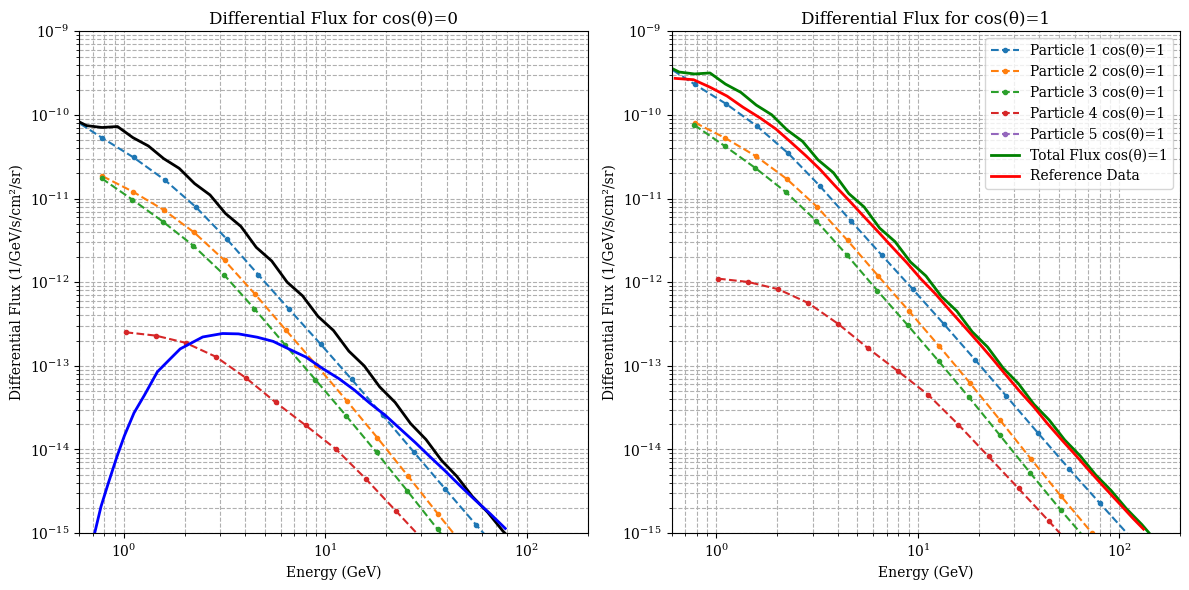

In [22]:
fig, ax = plt.subplots(1,2,figsize=(12, 6))
for i in range(len(E_chi_0)):
    ax[0].plot(E_chi_0[i][E_chi_0[i]<2e2], f_diff_0[i][E_chi_0[i]<2e2]/(2*np.pi), label=f'Particle {i+1} cos(θ)=0',ls = '--',marker = '.')
    ax[1].plot(E_chi_1[i][E_chi_1[i]<2e2], f_diff_1[i][E_chi_1[i]<2e2]/(2*np.pi), label=f'Particle {i+1} cos(θ)=1',ls = '--',marker = '.')
ax[0].plot(common_mass_0, flujo_total_0/(2*np.pi), label='Total Flux cos(θ)=0', color='black', linewidth=2)
ax[1].plot(common_mass_1, flujo_total_1/(2*np.pi), label='Total Flux cos(θ)=1', color='green', linewidth=2)
ax[1].plot(df['Ex'].values,df['flujo_dif'].values,label='Reference Data', color='red', linewidth=2)
ax[0].plot(df_0['Ex'].values,df_0['flujo_total'].values,label='Reference Data cos(θ)=0', color='blue', linewidth=2)
ax[0].set_xlabel('Energy (GeV)')
ax[0].set_ylabel('Differential Flux (1/GeV/s/cm²/sr)')
ax[1].set_xlabel('Energy (GeV)')
ax[1].set_ylabel('Differential Flux (1/GeV/s/cm²/sr)')
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')

ax[0].set_xlim([6e-1, 2e2])
ax[1].set_xlim([6e-1, 2e2])
ax[0].set_ylim([1e-15, 1e-9])
ax[1].set_ylim([1e-15, 1e-9])
ax[0].set_title('Differential Flux for cos(θ)=0')
ax[1].set_title('Differential Flux for cos(θ)=1')
plt.legend()
ax[0].grid(True, which="both", ls="--")
ax[1].grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

In [23]:
help(np.interp)

Help on method descriptor interp in module numpy:

interp(x, xp, fp, left=None, right=None, period=None)
    One-dimensional linear interpolation for monotonically increasing sample points.

    Returns the one-dimensional piecewise linear interpolant to a function
    with given discrete data points (`xp`, `fp`), evaluated at `x`.

    Parameters
    ----------
    x : array_like
        The x-coordinates at which to evaluate the interpolated values.

    xp : 1-D sequence of floats
        The x-coordinates of the data points, must be increasing if argument
        `period` is not specified. Otherwise, `xp` is internally sorted after
        normalizing the periodic boundaries with ``xp = xp % period``.

    fp : 1-D sequence of float or complex
        The y-coordinates of the data points, same length as `xp`.

    left : optional float or complex corresponding to fp
        Value to return for `x < xp[0]`, default is `fp[0]`.

    right : optional float or complex corresponding to 

In [24]:
common_mass_0

array([5.47850000e-01, 6.53446979e-01, 7.79397561e-01, 9.29624863e-01,
       1.10880817e+00, 1.32252871e+00, 1.57744344e+00, 1.88149247e+00,
       2.24414633e+00, 2.67670099e+00, 3.19262969e+00, 3.80800260e+00,
       4.54198739e+00, 5.41744627e+00, 6.46164807e+00, 7.70711766e+00,
       9.19264899e+00, 1.09645135e+01, 1.30779012e+01, 1.55986402e+01,
       1.86052466e+01, 2.21913702e+01, 2.64687119e+01, 3.15705025e+01,
       3.76556530e+01, 4.49137039e+01, 5.35707294e+01, 6.38963790e+01,
       7.62122767e+01, 9.09020388e+01, 1.08423223e+02, 1.29321580e+02,
       1.54248052e+02, 1.83979052e+02, 2.19440642e+02, 2.61737381e+02,
       3.12186732e+02, 3.72360093e+02, 4.44131747e+02, 5.29737242e+02,
       6.31843023e+02, 7.53629487e+02, 8.98890045e+02, 1.07214928e+03,
       1.27880389e+03, 1.52529075e+03, 1.81928745e+03, 2.16995142e+03,
       2.58820517e+03, 3.08707647e+03, 3.68210422e+03, 4.39182235e+03,
       5.23833722e+03, 6.24801611e+03, 7.45230857e+03, 8.88872596e+03,
      

In [25]:
def D_overburden(d,theta):
    '''
    Calculates the overburden distance D for a given depth d and zenith angle theta.
    d: depth in meters (of the experiment)
    theta: zenith angle in radians
    '''
    R_t = 6.378e6 # [m] Radio de la tierra
    D = np.sqrt((R_t-d)**2*((np.cos(theta))**2)+d*(2*R_t-d))-(R_t-d)*np.cos(theta)
    return D # resultado en METROS

# Función R
def R_average(eps, Ei, Ef, a=None, b=None):
    '''
    Calculates the average distance R that a mCP travels in the earth 
        eps: mCP charge fraction (e.g., 1e-3 for a mCP with charge 0.001e)
        Ei: initial energy of the mCP in the surface(in GeV)
        Ef: final energy of the mCP in the surface(in GeV)
        returns: R in meters using the formula R = (1/eps^2)*(1/b)*log((1+(a/b)*Ei)/(1+(a/b)*Ef))*(1/2.65)

    b is in 1/mwe units, so we may need to convert it to 1/m since D is 
    in meters. The paper says that this value was calculated for a "standard
    rock shielding so we consider 1 mwe = (1/2.65) m of rock "
    '''

    if a is None:
        a = 0.223 # [GeV/mwe]
    if b is None:
        b = 4.64e-4 # [1/mwe]

    R = ((1/(eps**2))*(1/b))*np.log((1+(b/a)*Ei)/(1+(b/a)*Ef)) # [mwe]
    R = R # [m]
    return R 

def P_arrival(eps, Ei, Ef, d, theta):
    '''
    Calculates the probability of arrival of a mCP at the detector given its charge fraction, initial and final energy, depth of the experiment, and zenith angle.
    eps: mCP charge fraction
    Ei: initial energy of the mCP in GeV
    Ef: final energy of the mCP in GeV
    d: depth of the experiment in meters
    theta: zenith angle in radians
    returns: probability of arrival at the detector
    '''
    D = D_overburden(d, theta)*2.65 # Calculate overburden distance D
    R = R_average(eps, Ei, Ef) # Calculate average distance R that the mCP travels in the earth
    P = np.exp(-D/R) # Probability of arrival using the formula P = exp(-D/R)
    return P

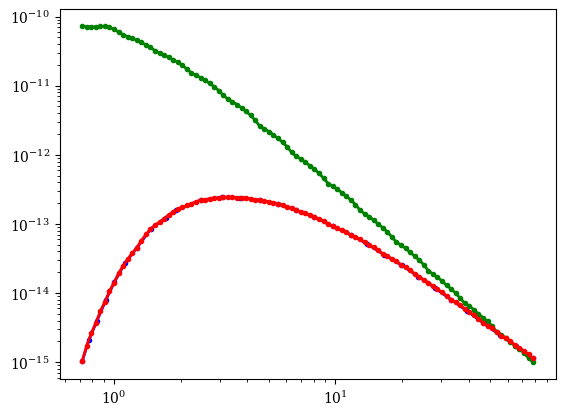

In [26]:
E = np.logspace(np.log10(np.min(df_0['Ex'].values)), np.log10(np.max(df_0['Ex'].values)), 100)
flux_1 = np.interp(E,common_mass_0, flujo_total_0/(2*np.pi))
flujo_LZ = np.interp(E,df_0['Ex'].values,df_0['flujo_total'].values)
plt.plot(df_0['Ex'].values,df_0['flujo_total'].values,label='Reference Data cos(θ)=0', color='blue',marker='.', linewidth=2)
plt.plot(E,flux_1,label='Interpolated Flux cos(θ)=1', color='green', marker = '.', linewidth=2)
plt.plot(E,flujo_LZ,label='Reference Data cos(θ)=1', color='red', marker = '.', linewidth=2)
plt.xscale('log')
plt.yscale('log')

In [27]:
cociente_ = (flujo_LZ/flux_1)
cociente = cociente_[cociente_ <1]

In [28]:
p_arrival = P_arrival((1e-4)**(1/2), E,0,1500, np.pi/2) # Example calculation for cos(theta)=1

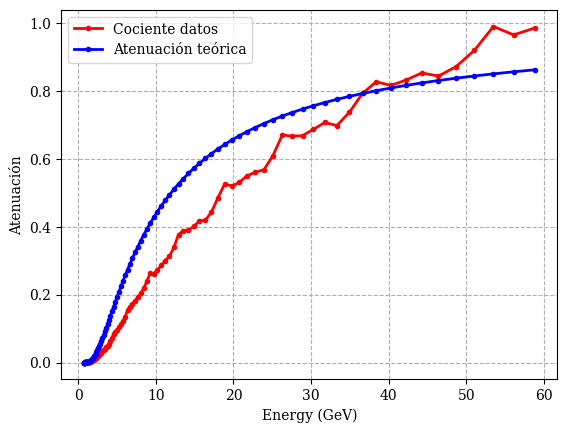

In [29]:
plt.plot(E[cociente_<1],cociente,label='Cociente datos', color='red', marker = '.', linewidth=2)
plt.plot(E[cociente_<1], p_arrival[cociente_<1], label='Atenuación teórica', color='blue', marker = '.', linewidth=2)
plt.xlabel('Energy (GeV)')
plt.ylabel('Atenuación')
plt.grid(linestyle='--')
plt.legend()

#plt.xscale('log')
#plt.yscale('log')


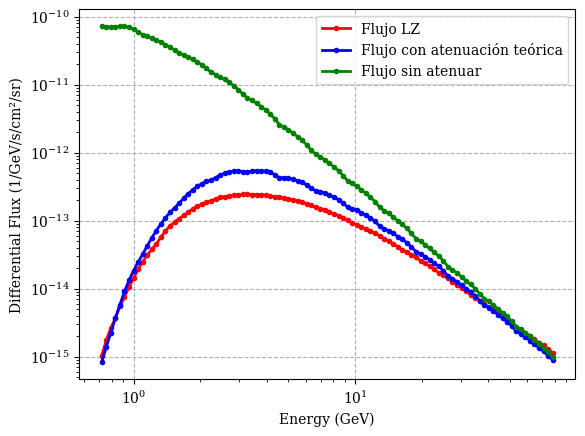

In [30]:
plt.plot(E,flujo_LZ,label='Flujo LZ', color='red', marker = '.', linewidth=2)
plt.plot(E,flux_1*p_arrival, label='Flujo con atenuación teórica', color='blue', marker = '.', linewidth=2)
plt.plot(E,flux_1,label='Flujo sin atenuar', color='green', marker = '.', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (GeV)')
plt.ylabel('Differential Flux (1/GeV/s/cm²/sr)')
plt.grid(linestyle='--')
plt.legend()